In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df= pd.read_csv("/content/clean ai job market data (1).csv")

#Total job Posting

In [32]:
df.shape[0]

10345

#Check missing values


In [33]:
df.isnull().sum()

,0
job_id,0
job_title,0
company_size,0
company_industry,0
country,0
remote_type,0
experience_level,0
years_experience,0
education_level,0
skills_python,0


#Fill missing value

In [34]:
df.fillna(0, inplace= True)

#Average Salary

In [35]:
print(df["salary"].dtype)

int64


In [36]:
df["salary"]= pd.to_numeric(df["salary"], errors= 'coerce')

In [37]:
df["salary"].mean()

np.float64(113438.22725954567)

#Top countries with most jobs

In [38]:
df["country"].value_counts().head(10)

,count
country,
Germany,1498
Singapore,1490
Canada,1488
UK,1485
India,1470
USA,1459
Australia,1455


#Top industry hires the most

In [39]:
df["company_industry"].value_counts().head(10)

,count
company_industry,
Technology,1787
E-commerce,1744
Finance,1724
Healthcare,1715
Education,1704
Retail,1671


#Most demanded skills

In [40]:
skills= df[["skills_python", "skills_sql", "skills_ml", "skills_deep_learning", "skills_cloud"]]
skills.sum()

,0
skills_python,5101
skills_sql,5204
skills_ml,5254
skills_deep_learning,5152
skills_cloud,5291


#Jobs requiring Python

In [41]:
df[df["skills_python"]==1]

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,...,hiring_urgency,job_openings,experience_category,salary_category,work_mode,total_skills_requried,date,month,year,posting_date
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,...,High,9,Entry Level,Low,Hybrid,4,14-03-1905,1,Jan-1900,01-01-1901
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,...,High,9,Senior Level,Low,Onsite,3,14-03-1905,1,Jan-1900,01-01-1901
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,...,Low,2,Mid Level,Low,Hybrid,3,14-03-1905,1,Jan-1900,01-01-1901
5,6,Machine Learning Engineer,Medium,Technology,Australia,Onsite,Senior,6,Master,1,...,High,2,Senior Level,Low,Onsite,3,14-03-1905,1,Jan-1900,01-01-1901
7,8,Data Analyst,Enterprise,Finance,UK,Onsite,Entry,4,PhD,1,...,High,7,Mid Level,Low,Onsite,3,14-03-1905,1,Jan-1900,01-01-1901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10336,10337,Data Scientist,Enterprise,Education,USA,Remote,Entry,13,Bachelor,1,...,Medium,5,Senior Level,Low,Work From Home,3,11-04-1905,4,Apr-1928,01-11-2763
10337,10338,Data Scientist,Enterprise,Technology,Singapore,Remote,Entry,12,PhD,1,...,Medium,3,Senior Level,Low,Work From Home,3,11-04-1905,4,Apr-1928,01-11-2763
10340,10341,Data Engineer,Startup,Technology,USA,Onsite,Entry,2,PhD,1,...,Low,4,Mid Level,Low,Onsite,3,11-04-1905,4,Apr-1928,01-11-2763
10341,10342,Data Analyst,Medium,Healthcare,Australia,Hybrid,Entry,10,Master,1,...,Medium,6,Senior Level,Low,Hybrid,3,11-04-1905,4,Apr-1928,01-11-2763


#Average salary by experience level

In [42]:
df.groupby("experience_level")['salary'].mean()

,salary
experience_level,
Entry,89095.872758
Mid,113592.018464
Senior,138289.091520


#Creating posting date column

In [43]:
df["posting_date"] =  pd.to_datetime(
    df["job_posting_year"].astype(str) + "-" +
    df["job_posting_month"].astype(str) + "-01"
)

#Salary distribution chart

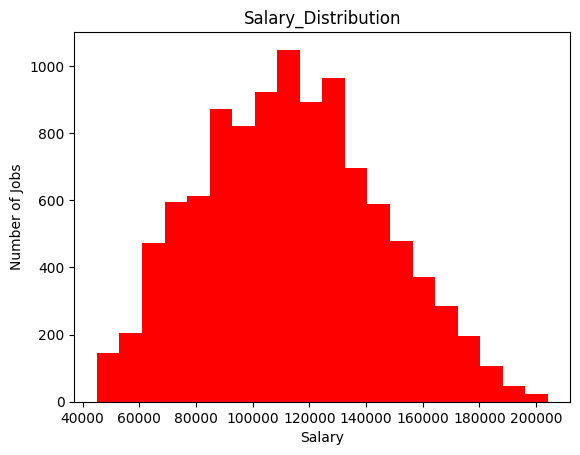

In [44]:
plt.hist(df["salary"], bins= 20, color="red")
plt.title("Salary_Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Jobs")
plt.show()

#Jobs by country

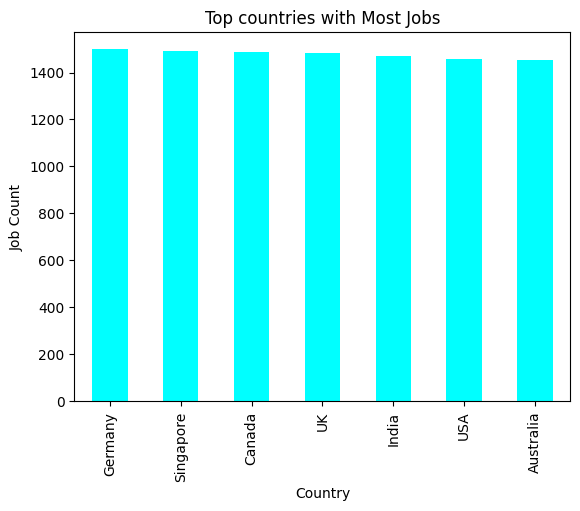

In [45]:
df["country"].value_counts().head(10).plot(kind= "bar", color= "cyan")
plt.title("Top countries with Most Jobs")
plt.xlabel("Country")
plt.ylabel("Job Count")
plt.show()

#Remote vs Onsite Jobs

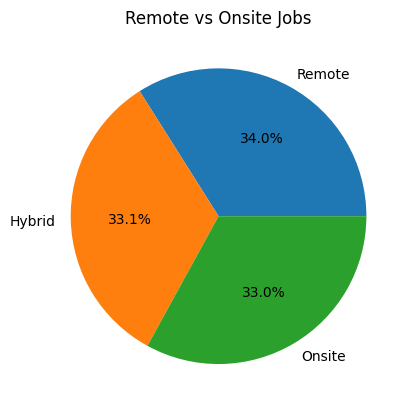

In [46]:
plt.pie(df["remote_type"].value_counts(),
        labels=df["remote_type"].value_counts().index,
        autopct='%1.1f%%')
plt.title("Remote vs Onsite Jobs")
plt.show()

#Experience Level vs Salary

/tmp/ipykernel_459/3434247596.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x= "experience_level", y= "salary", data= df, palette= "Set3")


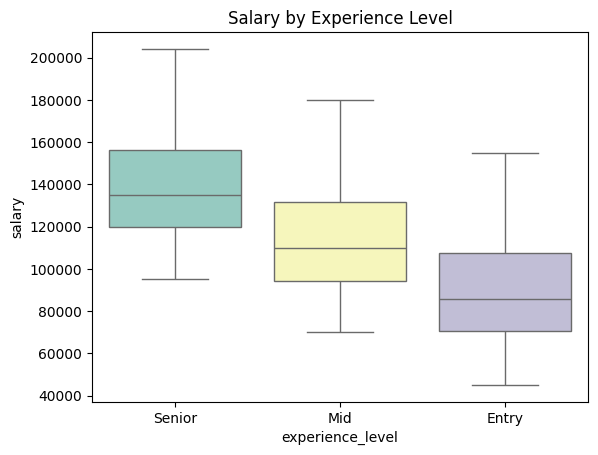

In [47]:
sns.boxplot(x= "experience_level", y= "salary", data= df, palette= "Set3")
plt.title("Salary by Experience Level")
plt.show()

#Skills Demand Chart

In [48]:
skills_sum= skills.sum()

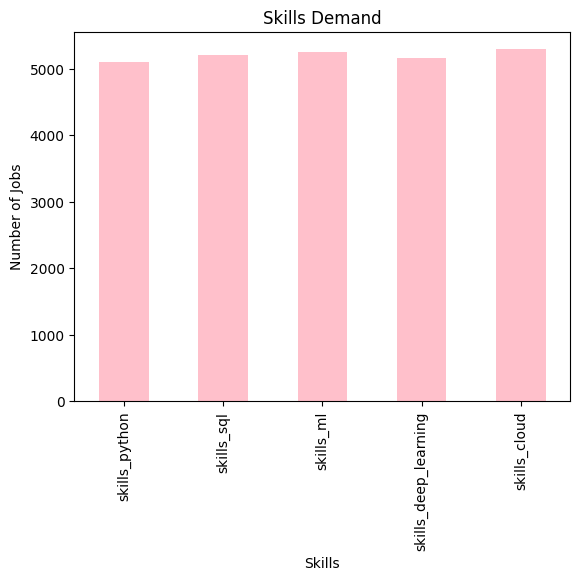

In [49]:
skills_sum.plot(kind= "bar", color= "pink")
plt.title("Skills Demand")
plt.xlabel("Skills")
plt.ylabel("Number of Jobs")
plt.show()

#Scatter Plot

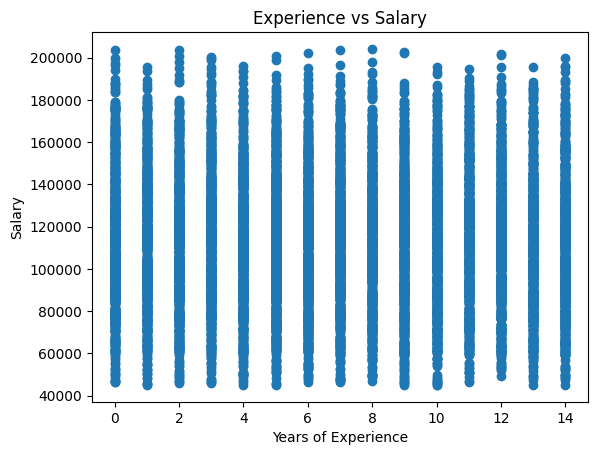

In [50]:
plt.scatter(df["years_experience"], df["salary"])
plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

#Heatmap (Correlation Analysis)

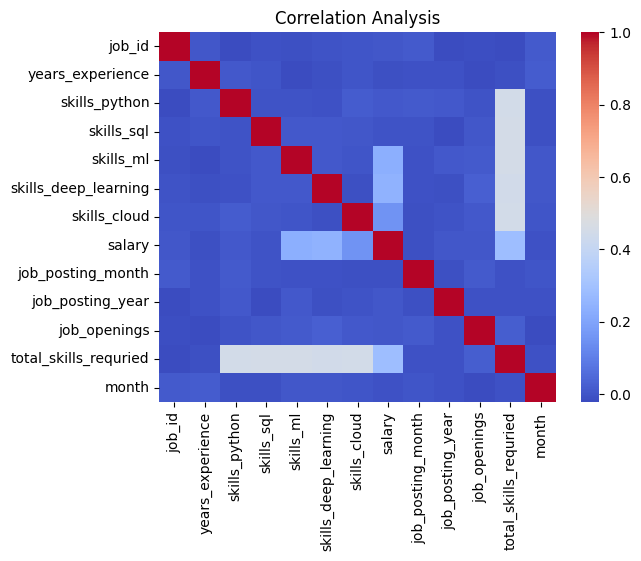

In [52]:
corr= df.corr(numeric_only= True)

sns.heatmap(corr, cmap= "coolwarm")
plt.title("Correlation Analysis")
plt.show()

#Map Visualization (Jobs by Country)

In [54]:
country_jobs= df.groupby("country").size().reset_index(name= "jobs")
import plotly.express as px
fig= px.choropleth(country_jobs,
                   locations= "country",
                   locationmode= "country names",
                   color= "jobs",
                   title= "Job Distribution by Country")
fig.show()

#Hiring Urgency Analysis

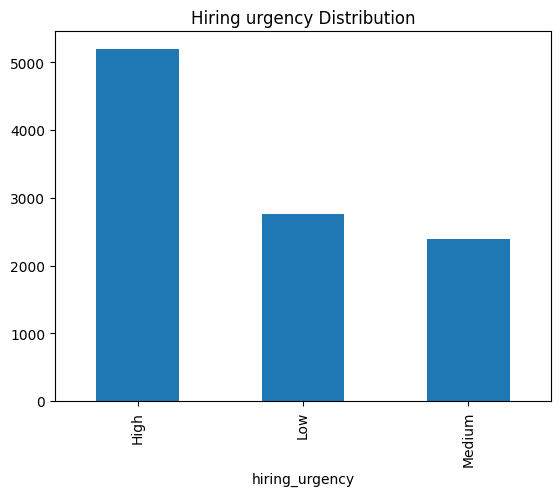

In [55]:
df["hiring_urgency"].value_counts().plot(kind= "bar")

plt.title("Hiring urgency Distribution")
plt.show()

#Job Openings by industry

In [56]:
df.groupby("company_industry")["job_openings"].sum().sort_values(ascending= False).head(10)

,job_openings
company_industry,
Technology,9149
E-commerce,8657
Finance,8654
Healthcare,8466
Retail,8440
Education,8401


#Salary by Education Level

In [57]:
df.groupby("education_level")["salary"].mean()

,salary
education_level,
Bachelor,113314.773223
Master,114018.731652
PhD,112962.324380


#Remote Jobs Average Salary

In [58]:
df.groupby("remote_type")["salary"].mean()

,salary
remote_type,
Hybrid,113363.757018
Onsite,113649.938453
Remote,113305.101623
